In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv(r"C:\Users\AROHI SINGH\Downloads\diabetes.csv")
print(df.head(5))

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [5]:
df.isnull().sum()


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [6]:
df.corr()["Outcome"].sort_values(ascending=False)

Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64

In [7]:
X=df.iloc[:, :-1].values
y=df.iloc[:, -1].values


In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [9]:
X =scaler.fit_transform(X)


In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
import tensorflow 
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [12]:
model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(8,))) #input layer = 8 because 8 columns
model.add(Dense(1, activation='relu')) #output layer
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

c:\Users\AROHI SINGH\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6515 - loss: 4.9116 - val_accuracy: 0.6558 - val_loss: 4.6338
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6450 - loss: 4.5083 - val_accuracy: 0.6753 - val_loss: 4.3270
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6596 - loss: 4.1444 - val_accuracy: 0.6688 - val_loss: 4.0822
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6580 - loss: 3.8513 - val_accuracy: 0.6494 - val_loss: 3.7862
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6612 - loss: 3.5333 - val_accuracy: 0.6558 - val_loss: 3.5941
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6726 - loss: 3.2668 - val_accuracy: 0.6883 - val_loss: 3.1359
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6808 - loss: 2.8641 - val_accuracy: 0.6558 - val_loss: 2.9265
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6873 - loss: 2.5600 - val_accuracy: 0.6688 - 

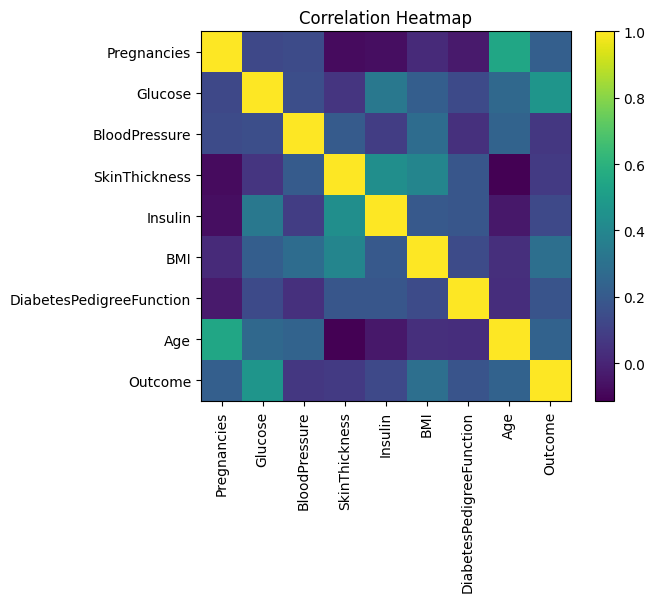

In [14]:
import matplotlib.pyplot as plt
import numpy as np

corr = df.corr()

plt.figure()
plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")
plt.show()

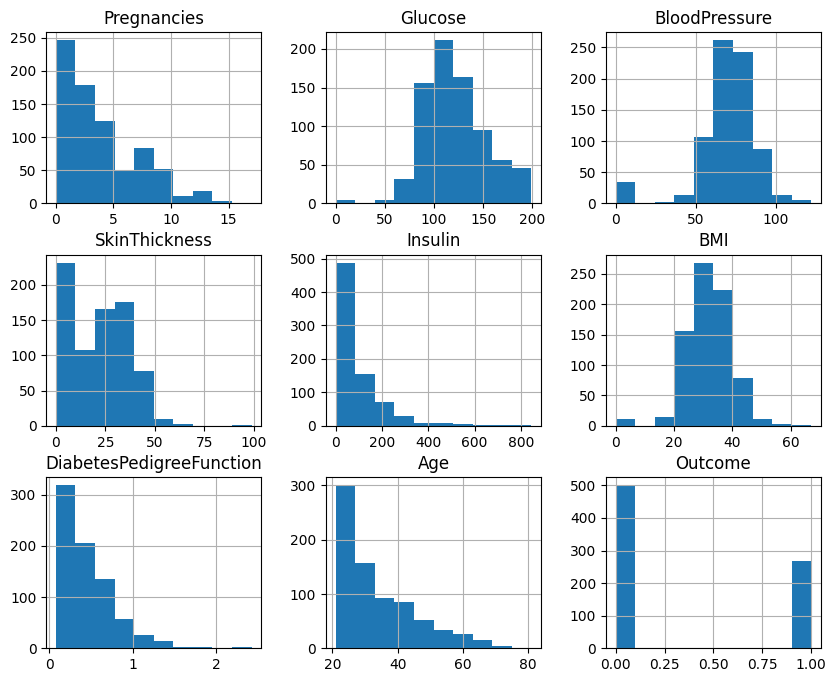

In [15]:
df.hist(figsize=(10, 8))
plt.show()


Glucose vs Outcome

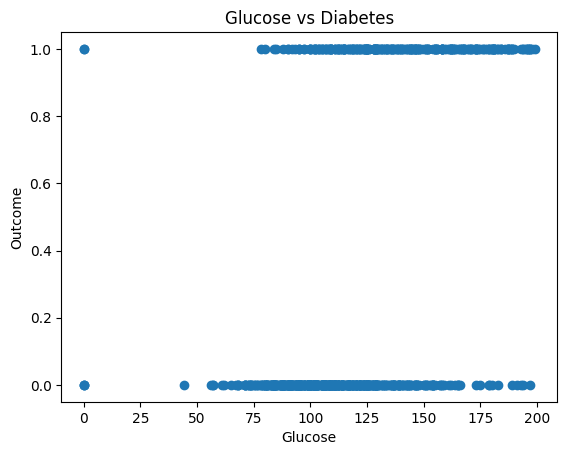

In [16]:
plt.figure()

plt.scatter(df['Glucose'], df['Outcome'])

plt.xlabel("Glucose")
plt.ylabel("Outcome")
plt.title("Glucose vs Diabetes")

plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


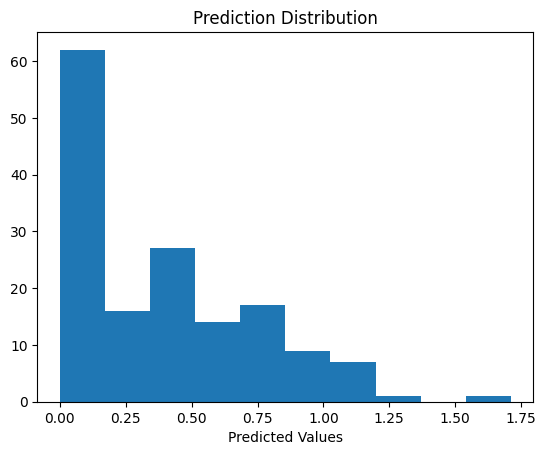

In [18]:
y_pred = model.predict(X_test)

plt.figure()

plt.hist(y_pred)

plt.title("Prediction Distribution")
plt.xlabel("Predicted Values")

plt.show()